In [608]:
import numpy as np
from scipy.signal import fftconvolve
from scipy.special import j1
from scipy.ndimage import shift as ndshift
import matplotlib.pyplot as plt

# ── camera sensor ──────────────────────────────────────────────────────────
H, W       = 256, 256   # camera frame [sensor pixels]
FWC        = 1e4        # full-well capacity [electrons]
RN         = 2.0        # readout noise sigma [ADC]
BIAS       = 0.0        # bias level [ADC]

# ── PSF sub-pixel model ────────────────────────────────────────────────────
R_AIRY_PX  = 1.0        # Airy first-dark-ring radius [camera pixels]
PSF_FINE   = 128        # fine-grid size for PSF [fine pixels, square]
OVERSAMPLE = 32         # fine pixels per camera pixel
#   PSF_FINE / OVERSAMPLE = 4×4 camera-pixel footprint per defect

# ── jitter interface (fine pixels) ────────────────────────────────────────
JITTER_MAX_SPX = OVERSAMPLE   # ±1 camera pixel max; reserved for future use

## model 

In [609]:
# ── 工具函数 ───────────────────────────────────────────────────────────────
def annotated_heatmap(ax, arr, title, fmt='{:.2f}', cmap='coolwarm', fontsize=8,
                      vmin=None, vmax=None):
    """Heatmap with per-cell value annotations.
    vmin/vmax: fixed color range for cross-panel comparison; None = auto.
    """
    im = ax.imshow(arr, cmap=cmap, interpolation='nearest', vmin=vmin, vmax=vmax)
    H, W = arr.shape
    threshold = arr.max() * 0.6 if arr.max() > 0 else 0.5
    for i in range(H):
        for j in range(W):
            ax.text(j, i, fmt.format(arr[i, j]), ha='center', va='center',
                    fontsize=fontsize,
                    color='black' if arr[i, j] > threshold else 'white')
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, shrink=0.75)
    return im

In [610]:
# ══════════════════════════════════════════════════════════════════════════
# Module 1 — PSF model
# ══════════════════════════════════════════════════════════════════════════

class PSF:
    def __init__(self, r_airy_px=R_AIRY_PX, psf_fine=PSF_FINE, oversample=OVERSAMPLE,
                 jitter_spx=0.0, jitter_spy=0.0, A=1.0):
        self.r_airy_px  = r_airy_px
        self.psf_fine   = psf_fine
        self.oversample = oversample
        self.jitter_spx = jitter_spx
        self.jitter_spy = jitter_spy
        self.A          = A

    @staticmethod
    def _bin2d(img, factor):
        H, W = img.shape
        H2, W2 = H // factor, W // factor
        return (img[:H2*factor, :W2*factor]
                .reshape(H2, factor, W2, factor)
                .sum(axis=(1, 3)))

    def make_fine(self, jitter_spx=None, jitter_spy=None):
        jx = self.jitter_spx if jitter_spx is None else jitter_spx
        jy = self.jitter_spy if jitter_spy is None else jitter_spy
        half = self.psf_fine // 2
        y, x = np.mgrid[-half:half, -half:half].astype(float)
        r = np.sqrt(x**2 + y**2)
        u_safe = np.where(r == 0, 1.0, 3.8317 * r / (self.r_airy_px * self.oversample))
        k = np.where(r == 0, 1.0, (2.0 * j1(u_safe) / u_safe)**2)
        k /= k.sum()
        if jx != 0.0 or jy != 0.0:
            k = ndshift(k, (jy, jx), order=3, mode='constant', cval=0.0)
        return k

    def make_template(self, A=None, jitter_spx=None, jitter_spy=None):
        """Camera-pixel PSF array, sum = A (default: self.A)."""
        a = self.A if A is None else A
        return self._bin2d(self.make_fine(jitter_spx, jitter_spy), self.oversample) * a

    def stamp(self, frame, x_px, y_px, A=None, jitter_spx=None, jitter_spy=None):
        """Add defect PSF centred at (x_px, y_px) into frame (in-place)."""
        tmpl = self.make_template(A, jitter_spx, jitter_spy)
        th, tw = tmpl.shape
        r0, c0 = y_px - th // 2, x_px - tw // 2
        r1, c1 = r0 + th, c0 + tw
        if r0 >= 0 and c0 >= 0 and r1 <= frame.shape[0] and c1 <= frame.shape[1]:
            frame[r0:r1, c0:c1] += tmpl

    def plot(self, A=None, jitter_spx=None, jitter_spy=None, figsize=(13, 4)):
        a      = self.A          if A          is None else A
        jx     = self.jitter_spx if jitter_spx is None else jitter_spx
        jy     = self.jitter_spy if jitter_spy is None else jitter_spy
        k_fine = self.make_fine(jx, jy)
        tmpl   = self.make_template(a, jx, jy)
        n_cam  = self.psf_fine // self.oversample

        fig, axes = plt.subplots(1, 3, figsize=figsize)
        axes[0].imshow(k_fine, cmap='hot', interpolation='nearest')
        axes[0].set_title(f'Airy PSF  {self.psf_fine}×{self.psf_fine} fine px\n'
                          f'r_airy={self.r_airy_px} cam-px = '
                          f'{self.r_airy_px*self.oversample:.0f} fine px')
        axes[1].imshow(k_fine, cmap='hot', interpolation='nearest')
        for i in range(0, self.psf_fine + 1, self.oversample):
            axes[1].axhline(i - 0.5, color='cyan', lw=0.8)
            axes[1].axvline(i - 0.5, color='cyan', lw=0.8)
        axes[1].set_title(f'Bin grid: {self.oversample}×{self.oversample} → 1 cam-px')
        annotated_heatmap(axes[2], tmpl,
                          f'Camera PSF {tmpl.shape[0]}×{tmpl.shape[1]} px\nsum={tmpl.sum():.4f}',
                          fmt='{:.4f}', fontsize=12)
        fig.suptitle(f'PSF  jitter=({jx},{jy}) fine-px  A={a}', fontsize=11)
        plt.tight_layout()
        plt.show()
        return k_fine, tmpl


# ── sanity check ──────────────────────────────────────────────────────────
psf = PSF()
_t  = psf.make_template()
_sz = PSF_FINE // OVERSAMPLE
print(f"Camera PSF  : {_t.shape}  sum={_t.sum():.2f}")
print(f"Inner 2×2   : {_t[_sz//2-1:_sz//2+1, _sz//2-1:_sz//2+1].sum():.2f}  "
      f"({_t[_sz//2-1:_sz//2+1, _sz//2-1:_sz//2+1].sum()/_t.sum()*100:.1f}%)")
print(_t)


Camera PSF  : (4, 4)  sum=1.00
Inner 2×2   : 0.91  (91.5%)
[[0.00312752 0.00886966 0.00898313 0.00324744]
 [0.00886966 0.21222408 0.22840376 0.00905769]
 [0.00898313 0.22840376 0.24583951 0.00915362]
 [0.00324744 0.00905769 0.00915362 0.00337828]]


In [611]:
# ══════════════════════════════════════════════════════════════════════════
# Module 2 — Background noise model
# ══════════════════════════════════════════════════════════════════════════

class Background:
    def __init__(self, H=H, W=W, rn=RN, bias=BIAS, rng=None):
        self.H    = H
        self.W    = W
        self.rn   = rn
        self.bias = bias
        self.rng  = rng if rng is not None else np.random.RandomState()

    def readout_noise(self):
        """Gaussian readout noise ~ N(bias, rn²)."""
        return self.bias + self.rng.normal(0.0, self.rn, size=(self.H, self.W))

    def sample(self):
        """Combined background frame (all active noise sources)."""
        return self.readout_noise()

    def create_figure(self, figsize=(8, 6), layout='horizontal'):
        if layout == 'horizontal':
            fig, axes = plt.subplots(1, 2, figsize=figsize,
                                     gridspec_kw={'width_ratios': [4, 1]})
        elif layout == 'vertical':
            fig, axes = plt.subplots(2, 1, figsize=figsize,
                                     gridspec_kw={'height_ratios': [4, 1]})
        else:
            raise ValueError("layout must be 'horizontal' or 'vertical'")
        return fig, axes

    def draw(self, axes, frame, title='', defects=None):
        ax_img, ax_hist = axes[0], axes[1]
        vmax = max(np.percentile(frame, 99.9), 3 * self.rn)
        im = ax_img.imshow(frame, cmap='gray', interpolation='nearest',
                           vmin=self.bias - 3 * self.rn, vmax=vmax, aspect='auto')
        if defects:
            for (xd, yd, _) in defects:
                ax_img.plot(xd, yd, 'c+', ms=8, mew=1.2)
        ax_img.set_title(title)
        plt.colorbar(im, ax=ax_img, label='ADC')
        ax_hist.hist(frame.ravel(), bins=100, density=True,
                     color='steelblue', alpha=0.7, orientation='horizontal')
        xg = np.linspace(frame.min(), frame.max(), 300)
        ax_hist.plot(
            np.exp(-0.5 * ((xg - self.bias) / self.rn)**2) / (self.rn * np.sqrt(2 * np.pi)),
            xg, 'r-', lw=1.5, label=f'N({self.bias},{self.rn}²)')
        ax_hist.set_xlabel('density'); ax_hist.legend(fontsize=8); ax_hist.grid(True)

    def plot(self, frame, title='', defects=None, layout='horizontal', figsize=(8, 6)):
        fig, axes = self.create_figure(figsize=figsize, layout=layout)
        self.draw(axes, frame, title, defects)
        plt.tight_layout()
        return fig, axes

### Module 3 — ImageLag forward model
根据lag_model 拟合后的参数带入

In [612]:
# ══════════════════════════════════════════════════════════════════════════
# Module 3 — ImageLag forward model
# ══════════════════════════════════════════════════════════════════════════

class ImageLag:
    """
    Hammerstein image-lag forward model — Q-dependent biexponential kernel.

        r(t, Q) = [Q − f(Q)]·δ(t=0) + f(Q)·h(t; f(Q))

        f(Q)   = Nt·(1−exp(−Q/Qc))                      静态非线性
        h(t;F) = A1(F)·g_fast(t) + (1−A1(F))·g_slow(t)  Q 依赖释放核
        A1(F)  = A1max·(1−exp(−F/Fc1))                   快陷阱占比
        g_slow = (1−α1)·α1^t / Σ,  g_fast = (1−α2)·α2^t / Σ  (窗口归一化)

    标定来源:
        Nt, Qc        : Mitscherlich 拟合  R²=0.996
        α1,α2,A1max,Fc1: 双指数联合全局优化 (lag_model_fit_test.ipynb)
    """

    # ── 默认标定参数 ──────────────────────────────────────────────────
    NT_DEFAULT     = 62.63
    QC_DEFAULT     = 85.4
    ALPHA1_DEFAULT = 0.7779   # 慢陷阱  τ1 ≈ 3.98 帧
    ALPHA2_DEFAULT = 0.2344   # 快陷阱  τ2 ≈ 0.69 帧
    A1MAX_DEFAULT  = 1.0
    FC1_DEFAULT    = 78.5     # 特征填充电荷 [DN]
    LEN_DEFAULT    = 20       # 拖尾窗口（帧）

    def __init__(self,
                 Nt=NT_DEFAULT, Qc=QC_DEFAULT,
                 alpha1=ALPHA1_DEFAULT, alpha2=ALPHA2_DEFAULT,
                 A1max=A1MAX_DEFAULT, Fc1=FC1_DEFAULT,
                 T=LEN_DEFAULT):
        self.Nt     = Nt
        self.Qc     = Qc
        self.alpha1 = alpha1
        self.alpha2 = alpha2
        self.A1max  = A1max
        self.Fc1    = Fc1
        self.T      = T

    # ── 静态非线性 ────────────────────────────────────────────────────
    def f_trap(self, Q):
        """Per-pixel 陷阱填充量"""
        return self.Nt * (1.0 - np.exp(-np.clip(Q, 0, None) / self.Qc))

    def remaining(self, Q):
        return Q - self.f_trap(Q)

    # ── 释放核 ────────────────────────────────────────────────────────
    def kernel(self, f=None):
        """
        Q 依赖双指数释放核，shape (1, T+1)，t=0 为占位 0，其余 Σ=1。
        f : f_trap 标量，None 时取 f→0（纯慢陷阱）。
        """
        f  = max(float(f), 1e-6) if f is not None else 1e-6
        t  = np.arange(1, self.T + 1)
        A1 = self.A1max * (1 - np.exp(-f / self.Fc1))
        g_sl = (1-self.alpha1)*self.alpha1**t;  g_sl /= g_sl.sum()
        g_fa = (1-self.alpha2)*self.alpha2**t;  g_fa /= g_fa.sum()
        h    = A1*g_fa + (1-A1)*g_sl
        return np.concatenate([[0.0], h]).reshape(1, -1)

    # ── 2D forward model ─────────────────────────────────────────────
    def apply(self, frame, return_parts=False):
        """
        线性叠加 forward model（逐像素 F 依赖核）。
        对每个有捕获的像素直接调用 self.kernel()。
        拖尾沿 axis=1（触发/读出方向）。
        """
        H, W    = frame.shape
        trapped = self.f_trap(frame)
        remain  = frame - trapped
        lag     = np.zeros((H, W))

        ys, xs = np.where(trapped > 0.01)
        for i, j in zip(ys, xs):
            k = self.kernel(trapped[i, j]).flatten()   # 该像素自己的 F → 你的 kernel
            n = min(self.T, W - 1 - j)                  # 不越右边界
            for dt in range(1, n + 1):
                lag[i, j + dt] += trapped[i, j] * k[dt]

        out = remain + lag
        if return_parts:
            return out, trapped, remain, lag
        return out

    # ── 标量冲激响应 ──────────────────────────────────────────────────
    def predict(self, Q, t_max=None):
        """单像素接受 Q DN 时的理论响应，返回 dict。"""
        T   = self.T if t_max is None else t_max
        fQ  = self.f_trap(Q)
        t   = np.arange(1, T + 1)
        A1  = self.A1max * (1 - np.exp(-max(float(fQ), 1e-6) / self.Fc1))
        g_sl = (1-self.alpha1)*self.alpha1**t;  g_sl /= g_sl.sum()
        g_fa = (1-self.alpha2)*self.alpha2**t;  g_fa /= g_fa.sum()
        lag  = fQ * (A1*g_fa + (1-A1)*g_sl)
        return {'peak': Q - fQ, 'lag': lag, 'fQ': fQ, 'A1': A1,
                'sum':  Q - fQ + lag.sum()}

    # ── 参数热更新 ────────────────────────────────────────────────────
    def update(self, **kwargs):
        for k, v in kwargs.items():
            if not hasattr(self, k):
                raise KeyError(f"未知参数: {k}")
            setattr(self, k, v)
        return self

    def __repr__(self):
        tau1 = -1 / np.log(self.alpha1)
        tau2 = -1 / np.log(self.alpha2)
        return (f"ImageLag(Nt={self.Nt}, Qc={self.Qc})\n"
                f"  slow: α1={self.alpha1:.4f}  τ1={tau1:.2f} 帧\n"
                f"  fast: α2={self.alpha2:.4f}  τ2={tau2:.2f} 帧\n"
                f"  A1(F) = {self.A1max} · (1−exp(−F/{self.Fc1}))")

### Module 4 — Detection filter + SNR

In [613]:
# ══════════════════════════════════════════════════════════════════════════
# Module 4 — Detection filter + SNR
# ══════════════════════════════════════════════════════════════════════════

class Filter:
    def __init__(self, rn=RN, bias=BIAS):
        self.rn   = rn
        self.bias = bias

    # ── Box map: n×m 均匀核滑动卷积响应图 ───────────────────────────
    def box_map(self, frame, n=2, m=2):
        """
        n×m 均匀核滑动卷积，返回每个位置的局部和响应图。
        减去 n*m*bias 扣除直流。
        """
        kernel = np.ones((n, m))
        resp   = fftconvolve(frame, kernel[::-1, ::-1], mode='same')
        return resp - n * m * self.bias

    # ── Box: 指定位置的 box_map 值 ────────────────────────────────────
    def box(self, frame, n=2, m=2):
        """box_map 全图最大值作为信号。"""
        return self.box_map(frame, n, m).max()

    # ── 匹配滤波器 ────────────────────────────────────────────────────
    def matched(self, frame, template):
        """归一化 MF 响应图。缺陷峰值 ≈ A·||template||，噪声 std ≈ RN。"""
        h    = template / np.linalg.norm(template)
        resp = fftconvolve(frame, h[::-1, ::-1], mode='same')
        return resp

    # ── Noise 1: 理论值 ───────────────────────────────────────────────
    def sigma_theory(self, n=2, m=2):
        """n×m box sum 理论噪声：sqrt(n*m)·RN。"""
        return np.sqrt(n * m) * self.rn

    # ── Noise 2: 经验值（远场响应图采样）─────────────────────────────
    def sigma_empirical(self, resp_map, cx, cy, n_samples=2000, excl_r=40, seed=0):
        """从响应图远场背景区采样取 std。excl_r: 排除半径 [pixels]。"""
        H, W = resp_map.shape
        rng  = np.random.RandomState(seed)
        vals = []
        while len(vals) < n_samples:
            ys = rng.randint(2, H - 2, n_samples)
            xs = rng.randint(2, W - 2, n_samples)
            for y, x in zip(ys, xs):
                if abs(y - cy) > excl_r or abs(x - cx) > excl_r:
                    vals.append(resp_map[y, x])
                if len(vals) >= n_samples:
                    break
        return np.std(vals[:n_samples])

    # ── 理论 SNR 上界（白噪声，MF）───────────────────────────────────
    def snr_theory(self, template, A):
        """MF SNR = A · ||template|| / RN"""
        return A * np.linalg.norm(template) / self.rn

    def __repr__(self):
        return (f"Filter(rn={self.rn}, bias={self.bias})\n"
                f"  sigma_theory(2×2) = {self.sigma_theory():.4f}")


# ── 快速验证 ──────────────────────────────────────────────────────────────
_flt  = Filter()
_tmpl = PSF().make_template(A=1.0)
print(_flt)
print(f"||h||      = {np.linalg.norm(_tmpl):.4f}")
for _A in [10, 50, 100]:
    print(f"  SNR_theory MF (A={_A:3d}) = {_flt.snr_theory(_tmpl, _A):.2f}")


Filter(rn=2.0, bias=0.0)
  sigma_theory(2×2) = 4.0000
||h||      = 0.4588
  SNR_theory MF (A= 10) = 2.29
  SNR_theory MF (A= 50) = 11.47
  SNR_theory MF (A=100) = 22.94


## test 

### show psf output

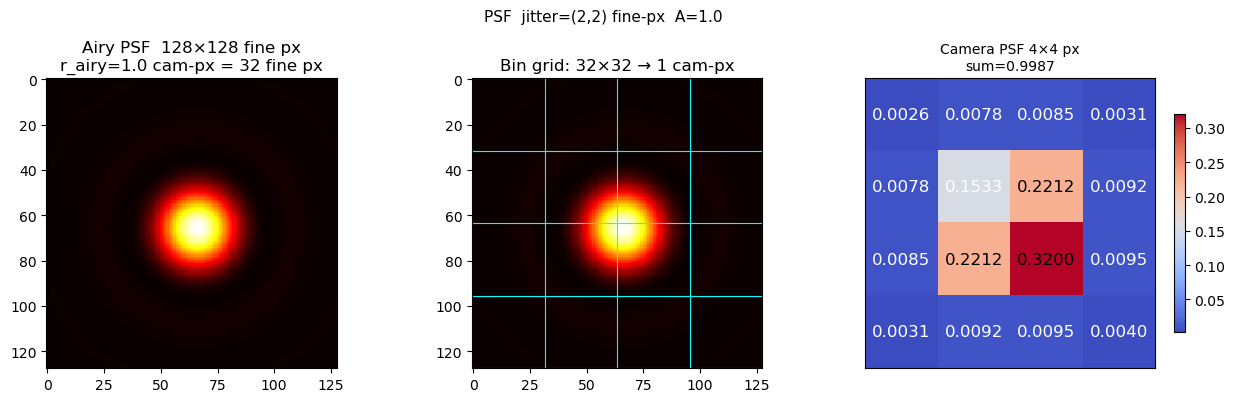

In [614]:
psf = PSF(jitter_spx=2, jitter_spy=2, A=1.0)
k_fine, tmpl = psf.plot()


### imagelag convolve psf test




ImageLag(Nt=62.63, Qc=85.4)
  slow: α1=0.7779  τ1=3.98 帧
  fast: α2=0.2344  τ2=0.69 帧
  A1(F) = 1.0 · (1−exp(−F/78.5))

Camera PSF: 4×4, sum=99.87, max=32.00
电荷守恒: Σin=99.87  Σout=99.87  差=-0.000 (-0.000%)


C:\Users\20250612\AppData\Local\Temp\ipykernel_60988\4028316139.py:76: UserWarning: Glyph 38745 (\N{CJK UNIFIED IDEOGRAPH-9759}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\20250612\AppData\Local\Temp\ipykernel_60988\4028316139.py:76: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\20250612\AppData\Local\Temp\ipykernel_60988\4028316139.py:76: UserWarning: Glyph 38750 (\N{CJK UNIFIED IDEOGRAPH-975E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\20250612\AppData\Local\Temp\ipykernel_60988\4028316139.py:76: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\20250612\AppData\Local\Temp\ipykernel_60988\4028316139.py:76: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\20250612\AppData\Local\Temp\ipykernel_60988\4028316139.py:76: UserWarni

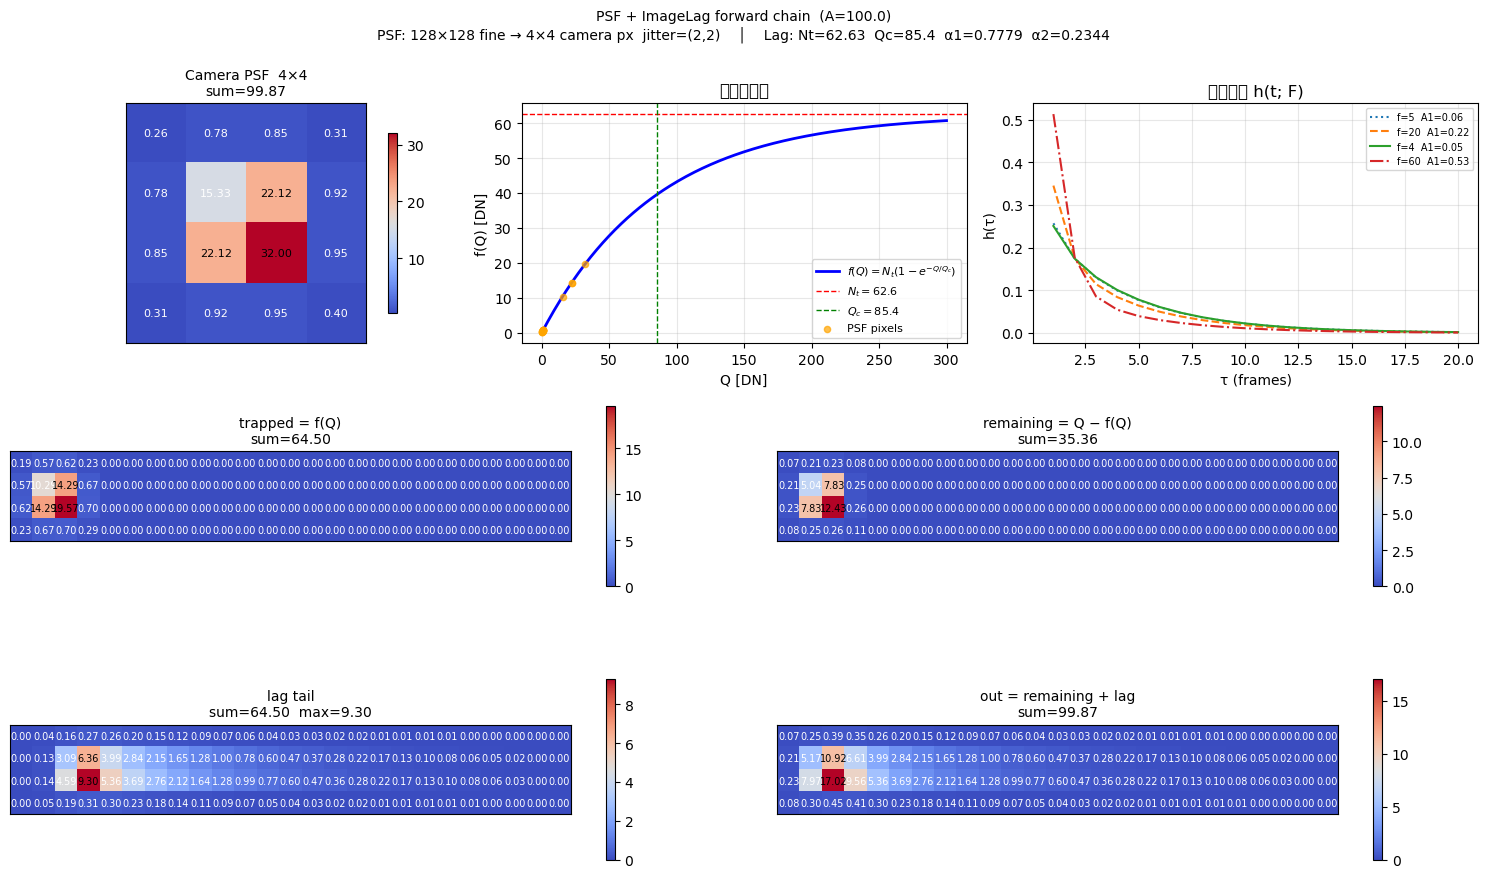

In [615]:
A   = 100.0
lag = ImageLag()
print(lag)

# ── Step 1: PSF 模板（使用 psf 存储的 jitter）────────────────────
tmpl_A = psf.make_template(A=A)
th, tw = tmpl_A.shape
print(f"\nCamera PSF: {th}×{tw}, sum={tmpl_A.sum():.2f}, max={tmpl_A.max():.2f}")

# ── Step 2: 嵌入 patch（右侧留 T 列给拖尾）───────────────────────
patch_w = tw + lag.T + 1
patch   = np.zeros((th, patch_w))
patch[:, :tw] = tmpl_A

# ── Step 3: lag forward ──────────────────────────────────────────
out, trapped, remaining, lag_only = lag.apply(patch, return_parts=True)
f_mean = float(trapped[trapped > 0.01].mean()) if (trapped > 0.01).any() else 1.0

sum_in, sum_out = patch.sum(), out.sum()
print(f"电荷守恒: Σin={sum_in:.2f}  Σout={sum_out:.2f}  "
      f"差={sum_in-sum_out:+.3f} ({(sum_in-sum_out)/sum_in*100:.3f}%)")

# ── 绘图 ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 9))

ax0 = plt.subplot2grid((3, 6), (0, 0), colspan=2)
annotated_heatmap(ax0, tmpl_A, f'Camera PSF  {th}×{tw}\nsum={tmpl_A.sum():.2f}',
                  fmt='{:.2f}', fontsize=8)

ax1 = plt.subplot2grid((3, 6), (0, 2), colspan=2)
Qs = np.linspace(0, max(300, A*1.2), 200)
ax1.plot(Qs, lag.f_trap(Qs), 'b-', lw=2, label=r'$f(Q)=N_t(1-e^{-Q/Q_c})$')
ax1.axhline(lag.Nt, color='r', ls='--', lw=1, label=f'$N_t={lag.Nt:.1f}$')
ax1.axvline(lag.Qc, color='g', ls='--', lw=1, label=f'$Q_c={lag.Qc:.1f}$')
ax1.scatter(tmpl_A.flatten(), lag.f_trap(tmpl_A.flatten()),
            c='orange', s=20, alpha=0.7, zorder=5, label='PSF pixels')
ax1.set_xlabel('Q [DN]'); ax1.set_ylabel('f(Q) [DN]')
ax1.set_title('静态非线性'); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

ax2 = plt.subplot2grid((3, 6), (0, 4), colspan=2)
t_arr = np.arange(1, lag.T + 1)
for f_val, ls in [(5, ':'), (20, '--'), (f_mean, '-'), (60, '-.')]:
    h_val = lag.kernel(f_val).flatten()[1:]
    A1_val = lag.A1max * (1 - np.exp(-f_val / lag.Fc1))
    ax2.plot(t_arr, h_val, ls, lw=1.5, label=f'f={f_val:.0f}  A1={A1_val:.2f}')
ax2.set_xlabel('τ (frames)'); ax2.set_ylabel('h(τ)')
ax2.set_title('双指数核 h(t; F)')
ax2.legend(fontsize=7); ax2.grid(alpha=0.3)

ax3 = plt.subplot2grid((3, 6), (1, 0), colspan=3)
annotated_heatmap(ax3, trapped,
                  f'trapped = f(Q)\nsum={trapped.sum():.2f}', fmt='{:.2f}', fontsize=7)

ax4 = plt.subplot2grid((3, 6), (1, 3), colspan=3)
annotated_heatmap(ax4, remaining,
                  f'remaining = Q − f(Q)\nsum={remaining.sum():.2f}', fmt='{:.2f}', fontsize=7)

ax5 = plt.subplot2grid((3, 6), (2, 0), colspan=3)
annotated_heatmap(ax5, lag_only,
                  f'lag tail\nsum={lag_only.sum():.2f}  max={lag_only.max():.2f}',
                  fmt='{:.2f}', fontsize=7)

ax6 = plt.subplot2grid((3, 6), (2, 3), colspan=3)
annotated_heatmap(ax6, out,
                  f'out = remaining + lag\nsum={out.sum():.2f}',
                  fmt='{:.2f}', fontsize=7)

n_cam = psf.psf_fine // psf.oversample
fig.suptitle(
    f'PSF + ImageLag forward chain  (A={A})\n'
    f'PSF: {psf.psf_fine}×{psf.psf_fine} fine → {n_cam}×{n_cam} camera px  '
    f'jitter=({psf.jitter_spx},{psf.jitter_spy})    │    '
    f'Lag: Nt={lag.Nt}  Qc={lag.Qc}  α1={lag.alpha1}  α2={lag.alpha2}',
    fontsize=10, y=0.995)

plt.tight_layout()
plt.savefig('psf_lag_integrated.png', dpi=120, bbox_inches='tight')
plt.show()


### background test

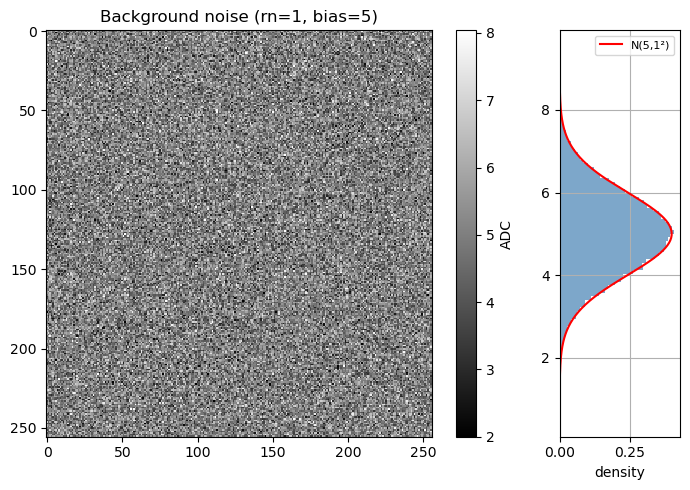

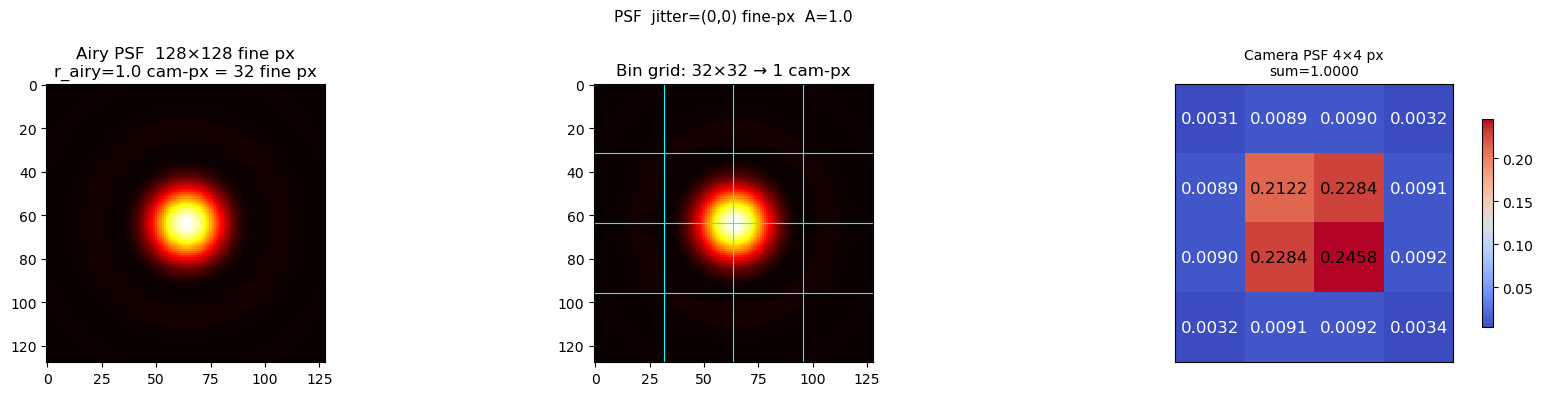

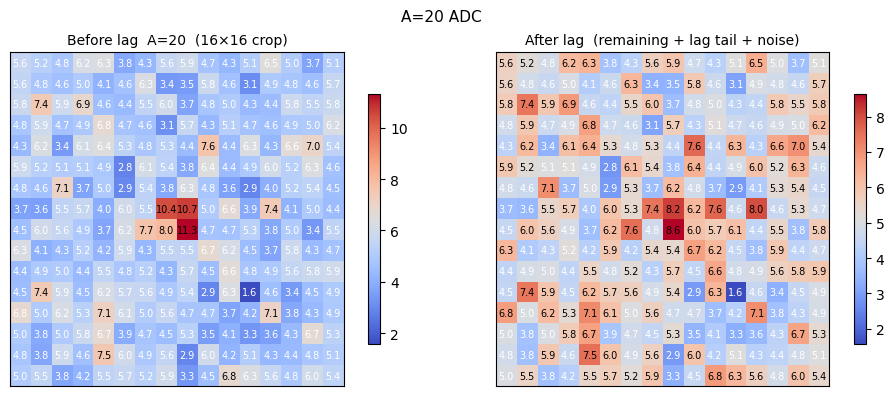

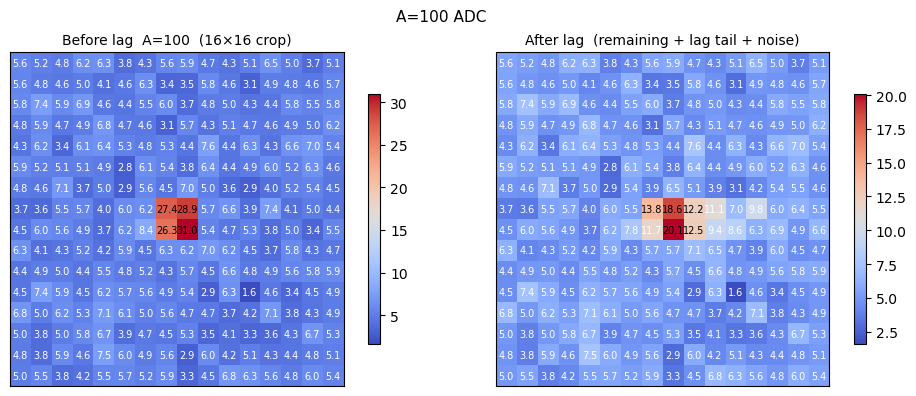

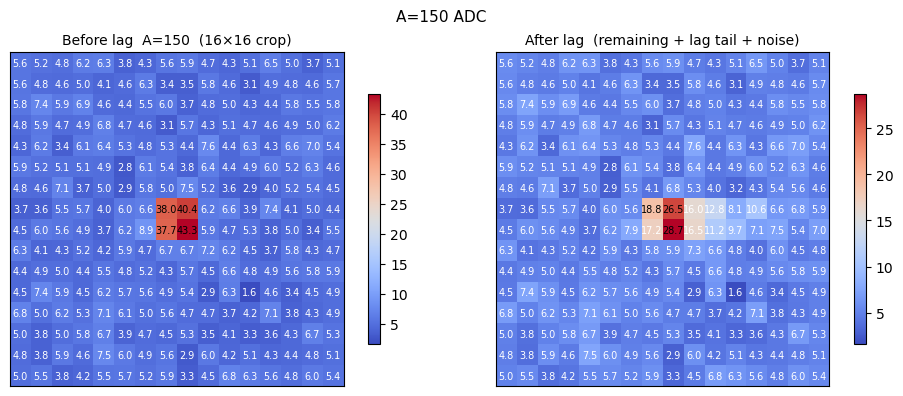

In [596]:
A_SHOW = [20, 100, 150]
cx, cy = W // 2, H // 2
half   = 8

bg    = Background(rn=1, bias=5, rng=np.random.RandomState(42))
psf = PSF(jitter_spx=0, jitter_spy=0, A=1.0)
noise = bg.sample()
bg.plot(noise, title='Background noise (rn=1, bias=5)', figsize=(7, 5))
plt.show()
psf.plot(figsize=(17, 4))
for A in A_SHOW:
    signal = np.zeros((H, W))
    psf.stamp(signal, cx, cy, A=A)
    out_signal, trapped, remaining, lag_only = lag.apply(signal, return_parts=True)
    frame = signal + noise
    out   = out_signal + noise

    sl = (slice(cy-half, cy+half), slice(cx-half, cx+half))

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    annotated_heatmap(axes[0], frame[sl],
                      f'Before lag  A={A}  ({half*2}×{half*2} crop)', fmt='{:.1f}', fontsize=7)
    annotated_heatmap(axes[1], out[sl],
                      f'After lag  (remaining + lag tail + noise)', fmt='{:.1f}', fontsize=7)
    fig.suptitle(f'A={A} ADC', fontsize=11)
    plt.tight_layout()
    plt.show()


### filter test

##### box_filter test

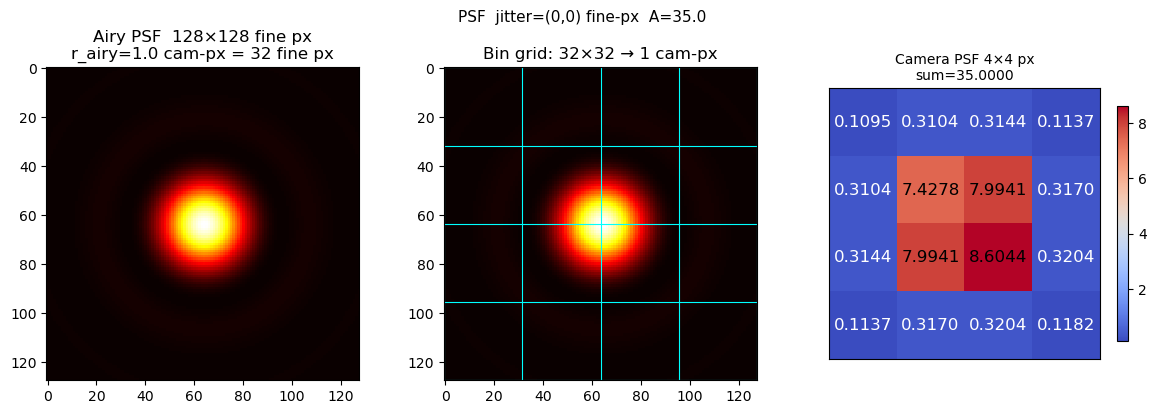

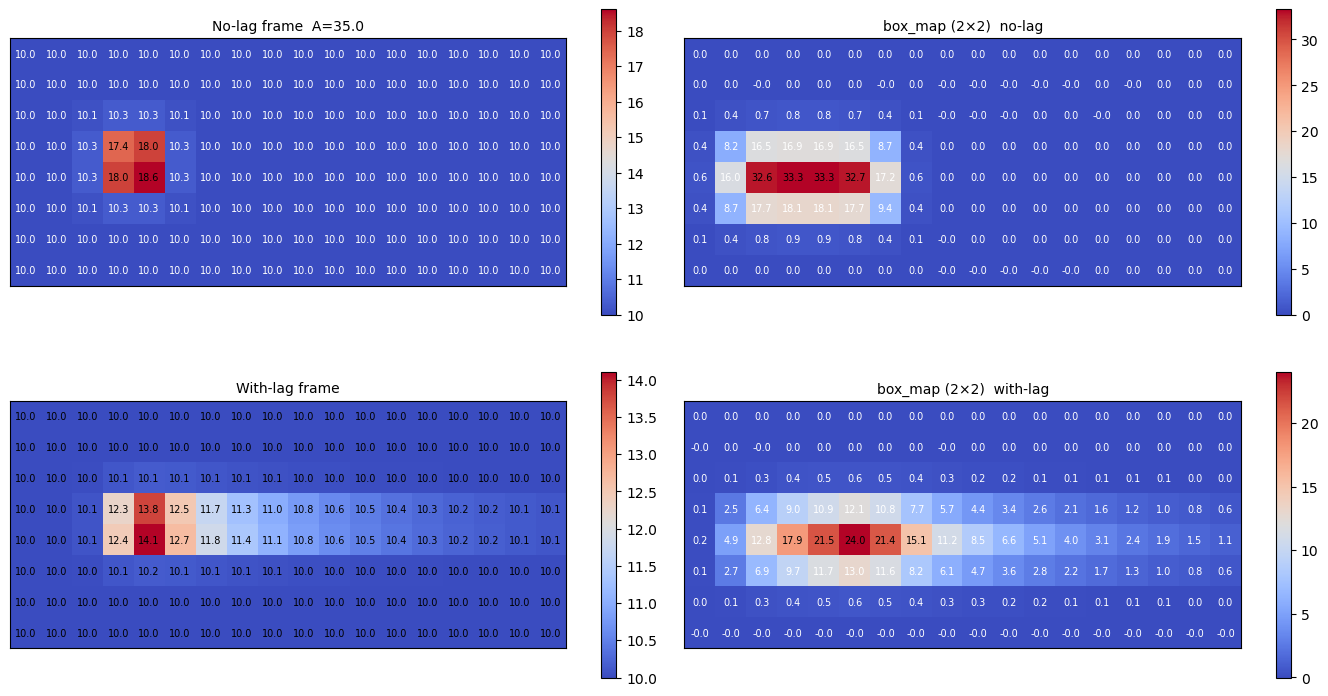

Case                    signal   sigma_th   sigma_emp    SNR_th   SNR_emp
-------------------------------------------------------------------------
Box (no lag)             33.28     0.0000      0.0000       inf  2297712310607320.50
Box (with lag)           24.01     0.0000      0.0000       inf  1689326464138144.00

SNR degradation (lag vs no-lag): 0.735x


C:\Users\20250612\AppData\Local\Temp\ipykernel_60988\1509277389.py:53: RuntimeWarning: divide by zero encountered in scalar divide
  f"  {s/sigma_th:8.2f}  {s/s_emp:8.2f}")


In [605]:
# ── Filter test: box SNR — no-lag vs with-lag ─────────────────────────────
A_TEST = 35.0
CX, CY = W // 2, H // 2
half   = 4
BIAS=10
RN=0
jitter_spx, jitter_spy = 0, 0
BOX_N, BOX_M = 2, 5   # ← 只改这里

psf_ft  = PSF(jitter_spx=jitter_spx, jitter_spy=jitter_spy, A=A_TEST)
psf_ft.plot(figsize=(12, 4))
tmpl_ft = psf_ft.make_template(A=1.0)
flt_    = Filter(rn=RN, bias=BIAS)
lag_    = ImageLag()
bg_ft   = Background(rn=RN, bias=BIAS, rng=np.random.RandomState(41))

noise_ = bg_ft.sample()
sig_   = np.zeros((H, W))
psf_ft.stamp(sig_, CX, CY)

frame_nl = sig_              + noise_
frame_wl = lag_.apply(sig_)  + noise_

# ── 全帧 box_map（2×2 均匀核）────────────────────────────────────────────
bmap_nl = flt_.box_map(frame_nl, n=BOX_N, m=BOX_M)
bmap_wl = flt_.box_map(frame_wl, n=BOX_N, m=BOX_M)

# ── Heatmap: frame + box_map，无lag与有lag并排 ───────────────────────────
sl  = (slice(CY - half, CY + half), slice(CX - half, CX + half + lag_.T // 2))
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
annotated_heatmap(axes[0, 0], frame_nl[sl], f'No-lag frame  A={A_TEST}',  fmt='{:.1f}', fontsize=7)
annotated_heatmap(axes[0, 1], bmap_nl[sl],  'box_map (2×2)  no-lag',      fmt='{:.1f}', fontsize=7)
annotated_heatmap(axes[1, 0], frame_wl[sl], 'With-lag frame',             fmt='{:.1f}', fontsize=7)
annotated_heatmap(axes[1, 1], bmap_wl[sl],  'box_map (2×2)  with-lag',    fmt='{:.1f}', fontsize=7)
plt.tight_layout()
plt.show()

# ── Signal & Noise ────────────────────────────────────────────────────────
s_nl = bmap_nl.max()
s_wl = bmap_wl.max()

sigma_th     = flt_.sigma_theory(n=BOX_N, m=BOX_M)
sigma_nl_emp = flt_.sigma_empirical(bmap_nl, CX, CY)
sigma_wl_emp = flt_.sigma_empirical(bmap_wl, CX, CY)

# ── Table ─────────────────────────────────────────────────────────────────
hdr = f"{'Case':20s}  {'signal':>8}  {'sigma_th':>9}  {'sigma_emp':>10}  {'SNR_th':>8}  {'SNR_emp':>8}"
print(hdr)
print('-' * len(hdr))
for name, s, s_emp in [('Box (no lag)',   s_nl, sigma_nl_emp),
                        ('Box (with lag)', s_wl, sigma_wl_emp)]:
    print(f"{name:20s}  {s:8.2f}  {sigma_th:9.4f}  {s_emp:10.4f}"
          f"  {s/sigma_th:8.2f}  {s/s_emp:8.2f}")

print(f"\nSNR degradation (lag vs no-lag): {(s_wl/sigma_wl_emp) / (s_nl/sigma_nl_emp):.3f}x")


### matching filter test

#### matching filter kernel

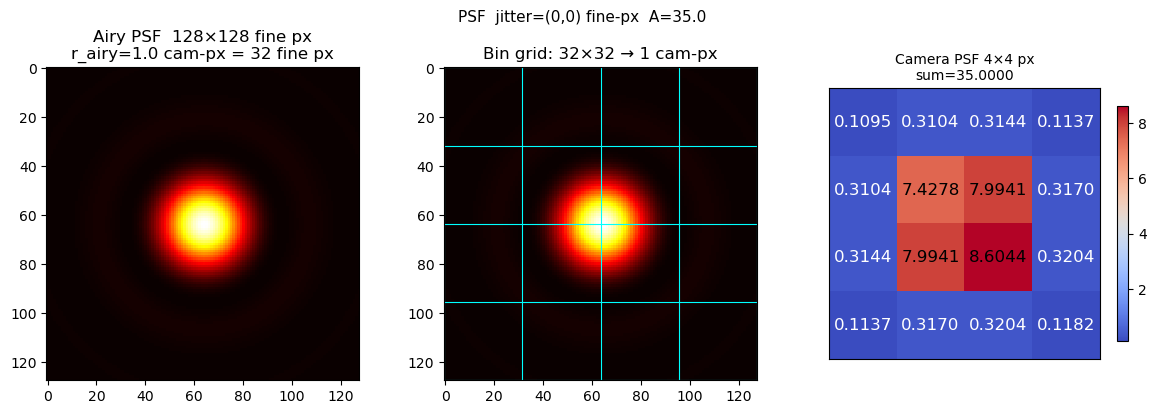

Template shape  : (2, 7)  (2 rows × 7 cols)
tmpl_lag.sum()  = 27.6682  (energy fraction captured: 79.1%)
||tmpl||        = 8.3052
SNR_theory (A=35) = ||tmpl|| / RN = inf


C:\Users\20250612\AppData\Local\Temp\ipykernel_60988\3158178359.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  f"{np.linalg.norm(tmpl_lag) / RN:.2f}")


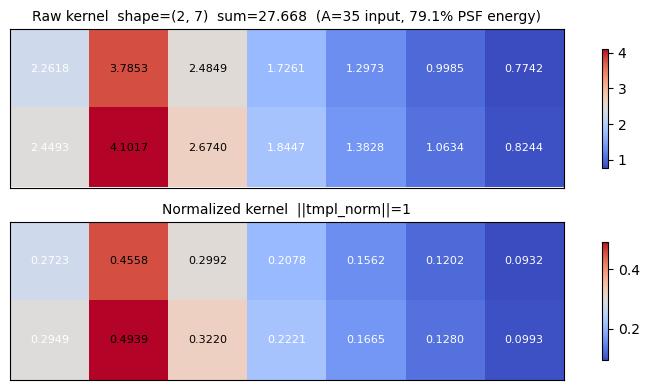

In [606]:
# ── Matched filter kernel: PSF full 4×4 rows + lag tail ──────────────────
# PSF 4×4 stamped at (CX, CY):  spans rows [CY-2, CY+2), cols [CX-2, CX+2)
# Lag tail extends rightward from the PSF right edge.
#
# Template built at A=A_TEST to match the operating amplitude.
# MF signal = A_TEST × ‖tmpl_lag‖.
#
# LAG_COLS: columns to keep after the PSF right outer edge (CX+1 inclusive).
# 0 = PSF 4×4 only.  Useful range: 1 … lag_.T (=20).
LAG_COLS = 5   # ← adjust here

TMPL_JX, TMPL_JY = 0, 0   # ← 改这里

sig_tmpl = np.zeros((H, W))
psf_MF = PSF(jitter_spx=TMPL_JX, jitter_spy=TMPL_JY, A=A_TEST)
psf_MF.stamp(sig_tmpl, CX, CY)
psf_MF.plot(figsize=(12, 4))

lr = lag_.apply(sig_tmpl)

# Row range: full PSF height (4 rows)
r0, r1 = CY - 1, CY + 1               # 4 rows
# Col range: PSF left outer edge … PSF right outer edge + LAG_COLS
c0, c1 = CX - 1, CX + 1 + LAG_COLS   # 4 PSF cols + LAG_COLS

tmpl_lag  = lr[r0:r1, c0:c1]
tmpl_norm = tmpl_lag / np.linalg.norm(tmpl_lag)

energy_frac = tmpl_lag.sum() / sig_tmpl.sum()
print(f"Template shape  : {tmpl_lag.shape}  ({r1-r0} rows × {c1-c0} cols)")
print(f"tmpl_lag.sum()  = {tmpl_lag.sum():.4f}  (energy fraction captured: {energy_frac*100:.1f}%)")
print(f"||tmpl||        = {np.linalg.norm(tmpl_lag):.4f}")
print(f"SNR_theory (A={A_TEST:.0f}) = ||tmpl|| / RN = "
      f"{np.linalg.norm(tmpl_lag) / RN:.2f}")

fig, axes = plt.subplots(2, 1, figsize=(max(8, c1-c0), 4))
annotated_heatmap(axes[0], tmpl_lag,
                  f'Raw kernel  shape={tmpl_lag.shape}  sum={tmpl_lag.sum():.3f}  '
                  f'(A={A_TEST:.0f} input, {energy_frac*100:.1f}% PSF energy)',
                  fmt='{:.4f}', fontsize=8)
annotated_heatmap(axes[1], tmpl_norm,
                  'Normalized kernel  ||tmpl_norm||=1',
                  fmt='{:.4f}', fontsize=8)
plt.tight_layout()
plt.show()


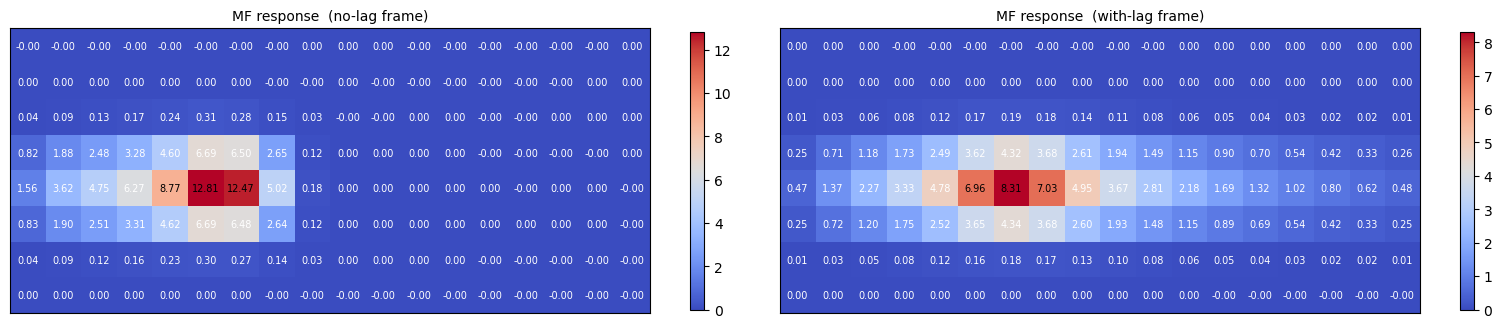

Case                            signal   sigma_th   sigma_emp    SNR_th   SNR_emp
---------------------------------------------------------------------------------
MF lag (no-lag frame)            12.81     0.0000      0.0000       inf  321892858996282112.00
MF lag (with-lag frame)           8.31     0.0000      0.0000       inf  286968298880319392.00


C:\Users\20250612\AppData\Local\Temp\ipykernel_60988\482182840.py:28: RuntimeWarning: divide by zero encountered in scalar divide
  f"  {s/sigma_mf_th:8.2f}  {s/s_emp:8.2f}")


In [607]:
# ── 应用 MF 到图像，计算 SNR ─────────────────────────────────────────────
resp_mf_nl = flt_.matched(frame_nl - flt_.bias, tmpl_lag)
resp_mf_wl = flt_.matched(frame_wl - flt_.bias, tmpl_lag)

# ── Heatmap（局部裁剪，与 box 一致）─────────────────────────────────────
sl_mf = (slice(CY - half, CY + half), slice(CX - half, CX + half + lag_.T // 2))
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
annotated_heatmap(axes[0], resp_mf_nl[sl_mf], 'MF response  (no-lag frame)',   fmt='{:.2f}', fontsize=7)
annotated_heatmap(axes[1], resp_mf_wl[sl_mf], 'MF response  (with-lag frame)', fmt='{:.2f}', fontsize=7)
plt.tight_layout()
plt.show()

# ── SNR 表格 ──────────────────────────────────────────────────────────────
s_mf_nl = resp_mf_nl.max()
s_mf_wl = resp_mf_wl.max()
sigma_mf_th     = flt_.rn
sigma_mf_nl_emp = flt_.sigma_empirical(resp_mf_nl, CX, CY)
sigma_mf_wl_emp = flt_.sigma_empirical(resp_mf_wl, CX, CY)

hdr = f"{'Case':28s}  {'signal':>8}  {'sigma_th':>9}  {'sigma_emp':>10}  {'SNR_th':>8}  {'SNR_emp':>8}"
print(hdr)
print('-' * len(hdr))
for name, s, s_emp in [
    ('MF lag (no-lag frame)',   s_mf_nl, sigma_mf_nl_emp),
    ('MF lag (with-lag frame)', s_mf_wl, sigma_mf_wl_emp),
]:
    print(f"{name:28s}  {s:8.2f}  {sigma_mf_th:9.4f}  {s_emp:10.4f}"
          f"  {s/sigma_mf_th:8.2f}  {s/s_emp:8.2f}")


MC kernel shape: (4, 24)  ||tmpl||=8.4319

Filter                      mean      std      min      max
-------------------------------------------------------
Box  (no lag)              33.96     2.24    29.37    39.60
Box  (with lag)            25.83     2.00    21.33    31.87
MF   (no lag)              41.64     3.10    35.02    50.67
MF   (with lag)            29.01     2.29    23.48    34.82


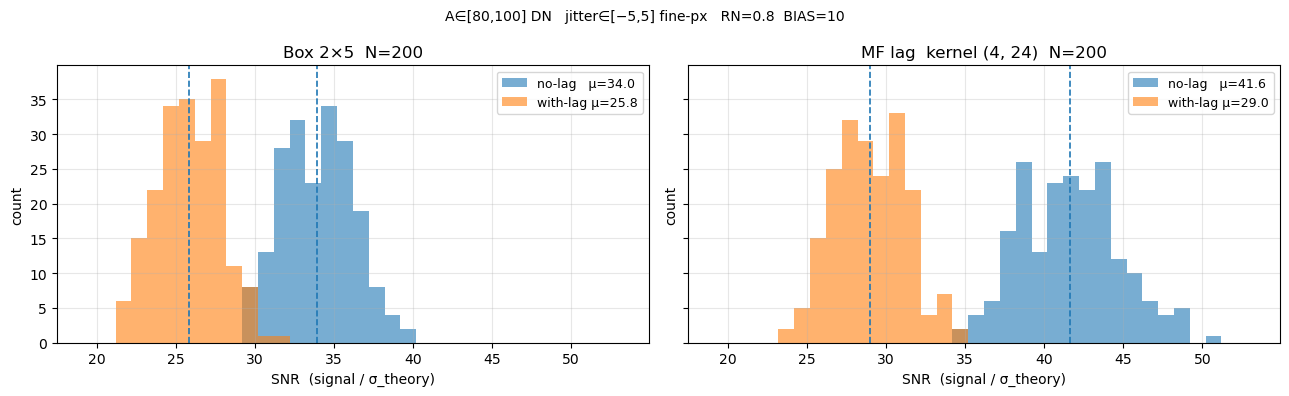

In [ ]:
# ── Monte Carlo: Box vs MF-lag  A∈[80,100]  jitter∈[-10,10] fine px ───────
N_MC   = 200
A_LO, A_HI   = 35, 100.0
JIT_MAX      = 5          # fine pixels, both x and y

# MF kernel: full 4-row PSF + complete lag tail (no-jitter reference)
_sig_t = np.zeros((H, W))
PSF(A=A_TEST).stamp(_sig_t, CX, CY)
_lr_t  = lag_.apply(_sig_t)
tmpl_mc = _lr_t[CY-2:CY+2, CX-2:CX+2+lag_.T]   # shape (4, T+4)
print(f"MC kernel shape: {tmpl_mc.shape}  ||tmpl||={np.linalg.norm(tmpl_mc):.4f}")

sigma_box_th = flt_.sigma_theory(n=BOX_N, m=BOX_M)
sigma_mf_th  = flt_.rn

rng_mc = np.random.RandomState(0)
snr = {k: [] for k in ['box_nl', 'box_wl', 'mf_nl', 'mf_wl']}

for _ in range(N_MC):
    A_i  = rng_mc.uniform(A_LO, A_HI)
    jx_i = rng_mc.uniform(-JIT_MAX, JIT_MAX)
    jy_i = rng_mc.uniform(-JIT_MAX, JIT_MAX)

    sig_i   = np.zeros((H, W))
    PSF(jitter_spx=jx_i, jitter_spy=jy_i, A=A_i).stamp(sig_i, CX, CY)
    noise_i = BIAS + rng_mc.normal(0.0, RN, (H, W))

    frame_nl_i = sig_i              + noise_i
    frame_wl_i = lag_.apply(sig_i)  + noise_i

    bmap_nl_i = flt_.box_map(frame_nl_i, n=BOX_N, m=BOX_M)
    bmap_wl_i = flt_.box_map(frame_wl_i, n=BOX_N, m=BOX_M)
    resp_nl_i = flt_.matched(frame_nl_i - flt_.bias, tmpl_mc)
    resp_wl_i = flt_.matched(frame_wl_i - flt_.bias, tmpl_mc)

    snr['box_nl'].append(bmap_nl_i.max() / sigma_box_th)
    snr['box_wl'].append(bmap_wl_i.max() / sigma_box_th)
    snr['mf_nl' ].append(resp_nl_i.max() / sigma_mf_th)
    snr['mf_wl' ].append(resp_wl_i.max() / sigma_mf_th)

snr = {k: np.array(v) for k, v in snr.items()}

print(f"\n{'Filter':22s}  {'mean':>8}  {'std':>7}  {'min':>7}  {'max':>7}")
print('-' * 55)
for k, label in [('box_nl','Box  (no lag)'), ('box_wl','Box  (with lag)'),
                  ('mf_nl', 'MF   (no lag)'), ('mf_wl', 'MF   (with lag)')]:
    v = snr[k]
    print(f"{label:22s}  {v.mean():8.2f}  {v.std():7.2f}  {v.min():7.2f}  {v.max():7.2f}")

# ── 直方图 ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
all_vals = np.concatenate(list(snr.values()))
bins = np.linspace(all_vals.min()*0.9, all_vals.max()*1.05, 35)

for ax, (k1, k2, title) in zip(axes, [
    ('box_nl', 'box_wl', f'Box {BOX_N}×{BOX_M}'),
    ('mf_nl',  'mf_wl',  f'MF lag  kernel {tmpl_mc.shape}')]):
    ax.hist(snr[k1], bins=bins, alpha=0.6, label=f'no-lag   μ={snr[k1].mean():.1f}')
    ax.hist(snr[k2], bins=bins, alpha=0.6, label=f'with-lag μ={snr[k2].mean():.1f}')
    ax.axvline(snr[k1].mean(), ls='--', lw=1.2)
    ax.axvline(snr[k2].mean(), ls='--', lw=1.2)
    ax.set_xlabel('SNR  (signal / σ_theory)')
    ax.set_ylabel('count')
    ax.set_title(f'{title}  N={N_MC}')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.suptitle(f'A∈[{A_LO:.0f},{A_HI:.0f}] DN   jitter∈[−{JIT_MAX},{JIT_MAX}] fine-px   '
             f'RN={RN}  BIAS={BIAS}', fontsize=10)
plt.tight_layout()
plt.show()

>20DN 测试
>2*5  BOX 波动 对比
蒙卡结果